In [1]:
import os
import pandas as pd
import numpy as np
from numpy import nan
import glob
import numba
import datetime
from scipy.stats import skew
import scipy.stats
from scipy import stats
import statsmodels.api as sm
import calendar
from scipy.optimize import differential_evolution
from multiprocessing import Pool
import warnings
import itertools
warnings.simplefilter(action='ignore', category=FutureWarning)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
from scipy.stats import genextreme as gev
from netCDF4 import Dataset
from scipy.stats import gumbel_r
from scipy.interpolate import interp1d
from scipy.stats import gumbel_r
from convertbng.util import convert_bng, convert_lonlat
from concurrent.futures import ProcessPoolExecutor, as_completed
from matplotlib.gridspec import GridSpec

In [2]:
def prepare_point_timeseries(df, season_definitions, completeness_threshold, durations, outlier_method,
        maximum_relative_difference, maximum_alterations,):
    """
    Prepare point timeseries for analysis.

    Steps are: (1) subset on reference calculation period, (2) define seasons for grouping, (3) applying any trimming
    or clipping to reduce the influence of outliers, and (4) aggregating timeseries to required durations.

    """
    # Check valid or nan  # TODO: Revisit if this function gets used for non-precipitation variables
    df.loc[df['value'] < 0.0] = np.nan

    # Apply season definitions and make a running UID for season that goes up by one at each change in season
    # through the time series. Season definitions are needed to identify season completeness but also to apply
    # trimming or clipping
    df['season'] = df.index.month.map(season_definitions)
    df['season_uid'] = df['season'].ne(df['season'].shift()).cumsum()

    # Mask periods not meeting data completeness threshold (close approximation). There is an assumption of at
    # least one complete version of each season in dataframe (where complete means that nans may be present - i.e.
    # fine unless only a very short (< 1 year) record is passed in)
    if df['value'].isnull().any():
        df['season_count'] = df.groupby('season_uid')['value'].transform('count')
        df['season_size'] = df.groupby('season_uid')['value'].transform('size')
        df['season_size'] = df.groupby('season')['season_size'].transform('median')
        df['completeness'] = df['season_count'] / df['season_size'] * 100.0
        df['completeness'] = np.where(df['completeness'] > 100.0, 100.0, df['completeness'])
        df.loc[df['completeness'] < completeness_threshold, 'value'] = np.nan
        df = df.loc[:, ['season', 'value']]

    # Apply trimming or clipping season-wise
    if outlier_method == 'trim':
        df['value'] = df.groupby('season')['value'].transform(
            trim_array(maximum_relative_difference, maximum_alterations)
        )
    elif outlier_method == 'clip':
        df['value'] = df.groupby('season')['value'].transform(
            clip_array(maximum_relative_difference, maximum_alterations)
        )

    # Find timestep and convert from datetime to period index if needed
    if not isinstance(df.index, pd.PeriodIndex):
        datetime_difference = df.index[1] - df.index[0]
    else:
        datetime_difference = df.index[1].to_timestamp() - df.index[0].to_timestamp()
    timestep_length = int(datetime_difference.days * 24) + int(datetime_difference.seconds / 3600)  # hours
    period = str(timestep_length) + 'H'  # TODO: Sort out sub-hourly timestep
    if not isinstance(df.index, pd.PeriodIndex):
        df = df.to_period(period)

    # TODO: More efficient approach would be to use successive durations in aggregation
    # - e.g use 1hr to get 3hr, but then use 3hr to get 6hr, 6hr to get 12hr, etc
    # - only works if there is a neat division, otherwise need to go back to e.g. 1hr

    # Prepare order to process durations in, so that long durations can be calculated from daily rather than hourly
    # durations (as faster)
    duration_hours = []
    for duration in durations:
        duration_units = duration[-1]
        if duration_units == 'H':
            duration_hours.append(int(duration[:-1]))
        elif duration_units == 'D':
            duration_hours.append(int(duration[:-1]) * 24)
        elif duration_units == 'M':
            duration_hours.append(31 * 24)
    duration_hours = np.asarray(duration_hours)
    sorted_durations = np.asarray(durations)[np.argsort(duration_hours)]

    # Aggregate timeseries to required durations
    dfs = {}
    for duration in sorted_durations:
        # resample_code = str(int(duration)) + 'H'  # TODO: Check/add sub-hourly
        resample_code = duration
        duration_units = duration[-1]
        if duration_units == 'H':
            duration_hours = int(duration[:-1])
        elif duration_units == 'D':
            duration_hours = int(duration[:-1]) * 24
        elif duration_units == 'M':
            duration_hours = 31 * 24

        # Final day needed for a given aggregation
        # - relies on multiples of one day if duration exceeds 24 hours
        # - constrained to monthly
        # - maximum duration of 28 days(?)
        if duration_hours > 24:
            duration_days = int(duration_hours / 24)

            # Interim aggregation to daily to see if it speeds things up
            if '24H' in durations:
                df1 = dfs['24H'].copy()
            elif '1D' in durations:
                df1 = dfs['1D'].copy()

            n_groups = int(np.ceil(31 / duration_days))
            df1['group'] = -1
            for group in range(n_groups):
                if duration_units != 'M':
                    df1['group'] = np.where(df1.index.day >= group * duration_days + 1, group, df1['group'])
                else:
                    # df1['month'] = df1.index.month
                    # df1['group'] = df1['month'].ne(df1['month'].shift()).cumsum()
                    # df1.drop(columns=['month'], inplace=True)
                    df1['group'] = 0

            # df1 = df.groupby([df.index.year, df.index.month, 'group'])['value'].agg(['sum', 'count'])
            df1 = df1.groupby([df1.index.year, df1.index.month, 'group'])['value'].agg(['sum', 'count'])
            if df1.index.names[0] == 'datetime':  # !221025 - for dfs coming from shuffling (fitting delta)
                df1.index.rename(['level_0', 'level_1', 'group'], inplace=True)
            df1.reset_index(inplace=True)
            df1['day'] = df1['group'] * duration_days + 1
            df1.rename(columns={'level_0': 'year', 'level_1': 'month'}, inplace=True)
            df1['datetime'] = pd.to_datetime(df1[['year', 'month', 'day']])
            df1.drop(columns=['year', 'month', 'day', 'group'], inplace=True)
            df1.set_index('datetime', inplace=True)
            # print(df1)
        else:
            df1 = df['value'].resample(resample_code, closed='left', label='left').agg(['sum', 'count'])
            
        # Remove data below a duration-dependent completeness
        if duration_hours <= 24:  # TODO: Remove hardcoding of timestep requiring complete data and completeness threshold?
            expected_count = int(duration_hours / timestep_length)
        else:
            expected_count = ((duration_hours / timestep_length) / 24) * 0.9  # TODO: Remove hardcoding - user option
        # df1.values[df2.values < expected_count] = np.nan  # duration
        df1.rename(columns={'sum': 'value'}, inplace=True)
        df1.loc[df1['count'] < expected_count, 'value'] = np.nan
        df1.drop(columns=['count'], inplace=True)
        df1.sort_index(inplace=True)
        # df1.drop(columns=['level_0'], inplace=True)

        df1['season'] = df1.index.month.map(season_definitions)

        dfs[duration] = df1
        dfs[duration] = dfs[duration][dfs[duration]['value'].notnull()]

    return dfs


def trim_array(max_relative_difference, max_removals):
    def f(x):
        y = x.copy()
        removals = 0
        while True:
            y_max = np.max(y)
            y_max_count = np.sum(y == y_max)
            y_next_largest = np.max(y[y < y_max])
            if y_max / y_next_largest > max_relative_difference:
                if removals + y_max_count <= max_removals:
                    y = y[y < y_max]
                    removals += y_max_count
                else:
                    break
            else:
                break
        return y  # , removals
    return f


def clip_array(max_relative_difference, max_clips):
    # - assuming working with zero-bounded values
    def f(x):
        y = x.copy()
        clips = 0
        clip_flag = -999
        while True:
            y_max = np.max(y)
            y_max_count = np.sum(y == y_max)
            y_next_largest = np.max(y[y < y_max])
            if y_max / y_next_largest > max_relative_difference:
                if clips + y_max_count <= max_clips:
                    y[y == y_max] = clip_flag
                    clips += y_max_count
                else:
                    break
            else:
                break
        y[y == clip_flag] = np.max(y)
        return y  # , clips
    return f

In [3]:

def prepare_weather_series(input_timeseries,input_variables,calculation_period,
    completeness_threshold,wet_threshold,season_length,point_id=1):
    
    # Read data
    #df = pd.read_csv(input_timeseries, index_col=0, parse_dates=True, infer_datetime_format=True)
    df = input_timeseries
    df.columns = [column.lower() for column in df.columns]

    # Assign month or half-month identifiers
    if season_length == 'half-month':
        df['season'] = identify_half_months(df.index)
    elif season_length == 'month':
        df['season'] = df.index.month

    # Subset on calculation period
    if calculation_period is not None:
        df = df.loc[(df.index.year >= calculation_period[0]) & (df.index.year <= calculation_period[1])]
    
    period_length = (datetime.datetime(calculation_period[1], 12, 31) - datetime.datetime(calculation_period[0], 1, 1))
    period_length = period_length.days + 1
    
    # Check enough data to continue
    if df.shape[0] >= 365:
        # Add wet day indicator
        df['wet_day'] = np.where(np.isfinite(df['prcp']) & (df['prcp'] >= wet_threshold), 1, 0)
        df['wet_day'] = np.where(~np.isfinite(df['prcp']), np.nan, df['wet_day'])

        # Compute derived temperature variables if present
        if 'temp_min' in df.columns and 'temp_max' in df.columns:
            df['temp_avg'] = (df['temp_min'] + df['temp_max']) / 2.0
            df['dtr'] = df['temp_max'] - df['temp_min']

        # Identify completeness by variable
        completeness = {}
        for variable in input_variables:
            if variable in df.columns:
                if df.shape[0] > 0:
                    if (variable in ['temp_avg', 'dtr']) and ('prcp' in df.columns):
                        completeness[variable] = (
                            np.sum(np.isfinite(df['prcp']) & np.isfinite(df[variable])) / period_length * 100
                        )
                    elif ('prcp' in df.columns) and ('temp_avg' in df.columns):
                        completeness[variable] = (
                            np.sum(
                                np.isfinite(df['prcp']) &
                                np.isfinite(df['temp_avg']) &
                                np.isfinite(df[variable])
                            ) / period_length * 100
                        )
                    else:
                        completeness[variable] = 0.0
                    completeness[variable] = min(completeness[variable], 100.0)
                    if completeness[variable] < completeness_threshold:
                        df.drop(columns=[variable], inplace=True)
                else:
                    completeness[variable] = 0.0
            else:
                completeness[variable] = 0.0

        # Need at least one variable to be sufficiently complete
        if max(completeness.values()) >= completeness_threshold:
            if 'datetime' not in df.columns:
                df.reset_index(inplace=True)

            # Reshape to long format
            df = pd.melt(df, id_vars=['datetime', 'season', 'prcp', 'wet_day'])

            # Filter relevant variables
            df = df.loc[~df['variable'].isin(['temp_mean', 'temp_min', 'temp_max', 'rel_hum'])]

            # Transition states
            df['wet_day_lag1'] = df['wet_day'].shift(1)
            df['wet_day_lag2'] = df['wet_day'].shift(2)
            df['transition'] = 'NA'
            df['transition'] = np.where((df['wet_day_lag1'] == 1) & (df['wet_day'] == 1), 'WW', df['transition'])
            df['transition'] = np.where((df['wet_day_lag1'] == 0) & (df['wet_day'] == 1), 'DW', df['transition'])
            df['transition'] = np.where((df['wet_day_lag1'] == 1) & (df['wet_day'] == 0), 'WD', df['transition'])
            df['transition'] = np.where((df['wet_day_lag1'] == 0) & (df['wet_day'] == 0), 'DD', df['transition'])
            df['transition'] = np.where(
                (df['wet_day_lag2'] == 0) & (df['wet_day_lag1'] == 0) & (df['wet_day'] == 0), 'DDD', df['transition']
            )
            df.drop(columns=['wet_day', 'wet_day_lag1', 'wet_day_lag2'], inplace=True)

            # Move precipitation into variable form
            tmp1 = df.loc[df['variable'] == df['variable'].unique()[0], ['datetime', 'season', 'transition', 'prcp']].copy()
            tmp1.rename(columns={'prcp': 'value'}, inplace=True)
            tmp1['variable'] = 'prcp'
            df.drop(columns=['prcp'], inplace=True)
            df = pd.concat([df, tmp1])

            # Compute seasonal stats and z-scores
            df1 = df.loc[df['transition'] != 'NA']
            df1 = df1.groupby(['variable', 'season'])['value'].agg(['mean', 'std']).reset_index()
            df = pd.merge(df, df1, on=['variable', 'season'])
            df['z_score'] = (df['value'] - df['mean']) / df['std']
            df.drop(columns=['mean', 'std'], inplace=True)

            # Add point ID
            df['point_id'] = point_id
            df1['point_id'] = point_id

        else:
            df, completeness, df1 = None, None, None

    else:
        df, completeness, df1 = None, None, None

    return df, df1, completeness


def identify_half_months(date_series):
    half_months = np.zeros(date_series.shape[0], dtype=int)
    current_half_month = 1
    for month in range(1, 13):
        half_months[(date_series.month == month) & (date_series.day <= 15)] = current_half_month
        current_half_month += 1
        half_months[(date_series.month == month) & (date_series.day > 15)] = current_half_month
        current_half_month += 1
    return half_months


In [4]:
# Given that we are dealing with HadUK dataset which has 10432 grids (5 KM grid size),
# a few additional steps are added
# which include extracting data from the NetCDF files for a given grid
# following that we begin the process of running the weather generator

GRIDS2 = pd.read_csv('/home/users/azhar199/DATA/NEWDATA/GRIDDED_WG_QC/HOURLY_DAILY/HUKMETA2.csv')
easting = GRIDS2['easting'].iloc[3736]
northing = GRIDS2['northing'].iloc[3736]

def prepare_haduk_weatherseries(prcp_file_path,tmax_file_path,tmin_file_path,NUM):
    
    RF_FILES = glob.glob(prcp_file_path+str('/*.nc'))[480:720]
    TEMP_MAX_FILES = glob.glob(tmax_file_path+str('/*.nc'))[480:720]
    TEMP_MIN_FILES = glob.glob(tmin_file_path+str('/*.nc'))[480:720]
    
    RFDS,MAXTEMP,MINTEMP = [[] for i in range(3)]
    for i in np.arange(0,len(RF_FILES),1):
        READ_RF = Dataset(RF_FILES[i])
        RF = READ_RF.variables['rainfall'][:,GRIDS2['HUK_y_index'][NUM],GRIDS2['HUK_x_index'][NUM]]
    
        READ_TMAX = Dataset(TEMP_MAX_FILES[i])
        tmax = READ_TMAX.variables['tasmax'][:,GRIDS2['HUK_y_index'][NUM],GRIDS2['HUK_x_index'][NUM]]
    
        READ_TMIN = Dataset(TEMP_MIN_FILES[i])
        tmin = READ_TMIN.variables['tasmin'][:,GRIDS2['HUK_y_index'][NUM],GRIDS2['HUK_x_index'][NUM]]
        
        RFDS.append(RF)
        MAXTEMP.append(tmax)
        MINTEMP.append(tmin)
        
    daily_weather_series = pd.DataFrame({'datetime':pd.date_range(start=pd.to_datetime('2001-01-01'), 
                                                              end=pd.to_datetime('2020-12-31'), freq="D"),
                                     'prcp':np.concatenate(RFDS),'temp_max':np.concatenate(MAXTEMP),
                                     'temp_min':np.concatenate(MINTEMP)})
    return daily_weather_series


daily_ws = prepare_haduk_weatherseries(prcp_file_path = '/home/users/azhar199/DATA/HADUK/HADUK_RF',
                            tmax_file_path = '/home/users/azhar199/DATA/HADUK/HADUK_TEMPMAX',
                            tmin_file_path = '/home/users/azhar199/DATA/HADUK/HADUK_TEMPMIN',
                            NUM = 3736)

daily_ws = daily_ws[daily_ws['datetime'].dt.year.isin(np.arange(2001,2021,1))].reset_index(drop=True)
dfb_daily = daily_ws[['datetime','prcp']]
dfb_daily = dfb_daily.rename(columns={'prcp': 'value'})
dfb_daily.index = dfb_daily['datetime']

SD = {12: 1, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2, 6: 3, 7: 3, 8: 3, 9: 4, 10: 4, 11: 4}    
ALLDF = prepare_point_timeseries(dfb_daily,season_definitions=SD,completeness_threshold=0,durations=['24H','72H','1M'], outlier_method='trim',maximum_relative_difference=2, maximum_alterations=5)

In [5]:
ALLDF['24H']['Year'] = ALLDF['24H'].index.year
ALLDF['24H']['Month'] = ALLDF['24H'].index.month
obs_annual_sum = (ALLDF['24H'].groupby('Year')['value'].sum().reset_index())
monthly_sum_df = (ALLDF['24H'].groupby(['Year', 'Month'])['value'].sum().reset_index())
obs_mon_mean = monthly_sum_df.groupby('Month')['value'].mean()

def fit_gumbel(rvs):
    loc, scale = gumbel_r.fit(rvs)
    return loc, scale

def gumbel_return_level(mu, sigma, T):
    return mu - sigma * np.log(-np.log(1 - 1/T))


OBS_MAX = ALLDF['24H'].groupby('Year')['value'].max()
GUMBEL_PAR = fit_gumbel(OBS_MAX)
RETURN_PERIODS = [2, 3, 5, 10, 15, 20, 25, 30]
RPVAL = [gumbel_return_level(mu=GUMBEL_PAR[0],sigma=GUMBEL_PAR[1],T=rp) for rp in RETURN_PERIODS]
RPVAL_DF_OBS = pd.DataFrame({'RP': RETURN_PERIODS,'RF': RPVAL})

In [6]:
n_realizations = 300
real_cols = [f"Realization_{i+1}" for i in range(n_realizations)]
MNU = ['M01','M04','M05','M06','M07','M08','M09','M10','M11','M12','M13','M15','M23','M25','M27','M29']
REAL_LIST = []
for datf in MNU:
    all_realizations_df = pd.read_csv(f'/home/users/azhar199/DATA/NEWDATA/GRIDDED_WG_QC/PaperPlots/UsageNotes/RFREAL_{datf}_Exeter.csv')
    monthly_sum_real = all_realizations_df.groupby(['Year', 'Month'])[real_cols].sum().reset_index()
    monthly_mean_real = monthly_sum_real.groupby('Month')[real_cols].mean().reset_index()
    REAL_LIST.append(monthly_mean_real)

monthly_mean_real = pd.concat(REAL_LIST,axis=0).reset_index(drop=True)
monthly_mean_real['Member'] = np.repeat(MNU,12)

In [7]:
REAL_RP_MEAN_LIST, DF_LONG_LIST = [[] for e in range(2)]
for datf in MNU:
    all_realizations_df = pd.read_csv(f'/home/users/azhar199/DATA/NEWDATA/GRIDDED_WG_QC/PaperPlots/UsageNotes/RFREAL_{datf}_Exeter.csv')
    REAL_MAX = []
    for col in real_cols:
        annual_max = all_realizations_df.groupby('Year')[col].max()
        REAL_MAX.append(annual_max)
    
    
    GUMBEL_PAR_REAL = [fit_gumbel(REAL_MAX[i]) for i in range(len(REAL_MAX))]
    RPVAL_DF_REAL = []
    
    for b in range(len(GUMBEL_PAR_REAL)):
        rpval = [gumbel_return_level(mu=GUMBEL_PAR_REAL[b][0],sigma=GUMBEL_PAR_REAL[b][1],T=rp) for rp in RETURN_PERIODS]
        rpval_df = pd.DataFrame({'RF': rpval})
        RPVAL_DF_REAL.append(rpval_df)
    
    
    REAL_RP_DF = pd.concat(RPVAL_DF_REAL, axis=1)
    REAL_RP_DF.columns = real_cols
    REAL_RP_DF['RP'] = RETURN_PERIODS
    
    
    REAL_RP_DF_CLEAN = REAL_RP_DF.copy()
    
    for idx in REAL_RP_DF_CLEAN.index:
        max_col = REAL_RP_DF_CLEAN.loc[idx,real_cols].idxmax()
        REAL_RP_DF_CLEAN.loc[idx, max_col] = np.nan
    
    df_long = REAL_RP_DF_CLEAN.melt(id_vars="RP",value_vars=real_cols,var_name="Realization",value_name="Value")
    REAL_RP_MEAN = pd.DataFrame(REAL_RP_DF_CLEAN[real_cols].mean(axis=1))
    REAL_RP_MEAN.columns = ['MEAN']
    REAL_RP_MEAN['Member'] = datf
    df_long['Member'] = datf
    REAL_RP_MEAN_LIST.append(REAL_RP_MEAN)
    DF_LONG_LIST.append(df_long)

/tmp/ipykernel_10636/3459809556.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  REAL_RP_DF['RP'] = RETURN_PERIODS
/tmp/ipykernel_10636/3459809556.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  REAL_RP_DF['RP'] = RETURN_PERIODS
/tmp/ipykernel_10636/3459809556.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfr

In [8]:
daily_ws.index = daily_ws['datetime']
CP1 =  pd.to_datetime(daily_ws['datetime'][0],format = '%Y-%m-%d').year
CP2 = pd.to_datetime(daily_ws['datetime'][daily_ws.shape[0]-1],format = '%Y-%m-%d').year
input_variables = ['temp_avg', 'dtr']
INPUT_WEATHER_SERIES = prepare_weather_series(input_timeseries = daily_ws, input_variables = input_variables,calculation_period = [CP1,CP2], completeness_threshold = 0,
                                              wet_threshold = 1, season_length = 'month', point_id=1)

OBS_TEMP = INPUT_WEATHER_SERIES[1][INPUT_WEATHER_SERIES[1]['variable'] == 'temp_avg']
OBS_DTR = INPUT_WEATHER_SERIES[1][INPUT_WEATHER_SERIES[1]['variable'] == 'dtr']
IWS = daily_ws
IWS['Year'] = [pd.to_datetime(IWS['datetime'][i],format = '%Y-%m-%d').year for i in range(IWS.shape[0])]
IWS['Month'] = [pd.to_datetime(IWS['datetime'][i],format = '%Y-%m-%d').month for i in range(IWS.shape[0])]
IWS2 = IWS[IWS['Year'].isin(np.arange(CP1,CP2+1,1))].reset_index(drop=True)
OBS_TEMPMIN = IWS2.groupby(['Year','Month'])['temp_min'].agg(np.mean).groupby('Month').agg(np.mean)
OBS_TEMPMAX = IWS2.groupby(['Year','Month'])['temp_max'].agg(np.mean).groupby('Month').agg(np.mean)

ANN_TMAX_THRES = np.quantile(daily_ws['temp_max'],0.9)
OBS_YEARLY_TMAX = ((daily_ws['temp_max'] > ANN_TMAX_THRES).groupby(daily_ws['Year']).sum())
OBS_MEAN_TMAX = OBS_YEARLY_TMAX.mean()

ANN_TMIN_THRES = np.quantile(daily_ws['temp_min'],0.9)
OBS_YEARLY_TMIN = ((daily_ws['temp_min'] > ANN_TMIN_THRES).groupby(daily_ws['Year']).sum())
OBS_MEAN_TMIN = OBS_YEARLY_TMIN.mean()

ANN_TMIN_COLD_THRES = np.quantile(daily_ws['temp_min'],0.1)
OBS_YEARLY_TMIN_COLD = ((daily_ws['temp_min'] < ANN_TMIN_COLD_THRES).groupby(daily_ws['Year']).sum())
OBS_MEAN_TMIN_COLD = OBS_YEARLY_TMIN_COLD.mean()

HW = daily_ws.copy()
HW['hot'] = HW['temp_max'] > ANN_TMAX_THRES
HW = HW.sort_index()

HW['group'] = (HW.index.to_series().diff().dt.days.ne(1).cumsum())
HW_hot = HW[HW['hot']].copy()
HW_hot['group'] = (HW_hot.index.to_series().diff().dt.days.ne(1).cumsum())
spells = (HW_hot.groupby('group').agg(start=('datetime','min'),end=('datetime','max'),duration=('datetime','count'),Year=('Year','first')))
HWDI = spells[spells['duration'] >= 6]
HWDI_YEAR = (HWDI.groupby('Year')['duration'].max())
OBS_HWDI = HWDI_YEAR.mean()

In [9]:
def GetTempReal(datf):
    TEMP_AVG_filled = pd.read_csv(f'/home/users/azhar199/DATA/NEWDATA/GRIDDED_WG_QC/PaperPlots/UsageNotes/TEMPREAL_{datf}_Exeter.csv')
    real_cols = [c for c in TEMP_AVG_filled.columns if c.startswith('R_')]
    realR = TEMP_AVG_filled.copy()
    realR.index = pd.to_datetime(TEMP_AVG_filled.iloc[:, 0])
    realR = realR.drop('Unnamed: 0',axis=1)
    monthly = realR.groupby(realR.index.month).mean()
    temp_mean = monthly.mean(axis=1)
    temp_low  = monthly.quantile(0.10, axis=1)
    temp_high = monthly.quantile(0.90, axis=1)
    FINDF = pd.DataFrame({'Member':datf,'Month':np.arange(1,13),'temp_mean':temp_mean,'temp_low':temp_low,'temp_high':temp_high}).reset_index(drop=True)
    return FINDF

TEMPDF = pd.concat([GetTempReal(datf) for datf in MNU]).reset_index(drop=True)

In [10]:
def GetTempHWDI(datf):
    TEMP_AVG_filled = pd.read_csv(f'/home/users/azhar199/DATA/NEWDATA/GRIDDED_WG_QC/PaperPlots/UsageNotes/TEMPREAL_{datf}_Exeter.csv')
    realR1 = TEMP_AVG_filled.copy()
    realR1.index = pd.to_datetime(TEMP_AVG_filled.iloc[:, 0])
    realR1 = realR1.drop('Unnamed: 0',axis=1)
    DTR_filled = pd.read_csv(f'/home/users/azhar199/DATA/NEWDATA/GRIDDED_WG_QC/PaperPlots/UsageNotes/DTRREAL_{datf}_Exeter.csv')
    realR2 = DTR_filled.copy()
    realR2.index = pd.to_datetime(DTR_filled.iloc[:, 0])
    realR2 = realR2.drop('Unnamed: 0',axis=1)
    TEMP_MIN = realR1 - (0.5*realR2)
    TEMP_MAX = realR1 + (0.5*realR2)

    REAL_HOT, REAL_WARM, REAL_COLD = [[] for w in range(3)]
    
    for col in TEMP_MAX.columns:
        yearly = ((TEMP_MAX[col] > ANN_TMAX_THRES).groupby(TEMP_MAX.index.year).sum())
        REAL_HOT.append(yearly.mean())
    
    for col in TEMP_MIN.columns:
        yearly = ((TEMP_MIN[col] > ANN_TMIN_THRES).groupby(TEMP_MIN.index.year).sum())
        REAL_WARM.append(yearly.mean())
    
    for col in TEMP_MIN.columns:
        yearly = ((TEMP_MIN[col] < ANN_TMIN_COLD_THRES).groupby(TEMP_MIN.index.year).sum())
        REAL_COLD.append(yearly.mean())
    
    REAL_HOT=np.array(REAL_HOT)
    REAL_WARM=np.array(REAL_WARM)
    REAL_COLD=np.array(REAL_COLD)
    
    REAL_HWDI = []
    for col in TEMP_MAX.columns:
        ts = TEMP_MAX[col]
        thresh = ANN_TMAX_THRES   
        hot = ts > thresh
        df = pd.DataFrame({'temp': ts,'hot': hot})
        df['Year'] = df.index.year
        hot_df = df[df['hot']].copy()
        hot_df['group'] = (hot_df.index.to_series().diff().dt.days.ne(1).cumsum())
        spells = (hot_df.groupby('group').agg(duration=('temp','size'),Year=('Year','first')))
        spells = spells[spells['duration'] >= 6]
        yearly = (spells.groupby('Year')['duration'].max())
        if len(yearly) == 0:
            REAL_HWDI.append(0)
        else:
            REAL_HWDI.append(yearly.mean())
    
    REAL_HWDI = np.array(REAL_HWDI)
    return pd.DataFrame({'Member':datf,'Hot days':REAL_HOT,'Warm Nights':REAL_WARM,'Cold Nights':REAL_COLD,'HWDI':REAL_HWDI}) 


HEAT_INDICES_REAL =  pd.concat([GetTempHWDI(datf) for datf in MNU]).reset_index(drop=True)

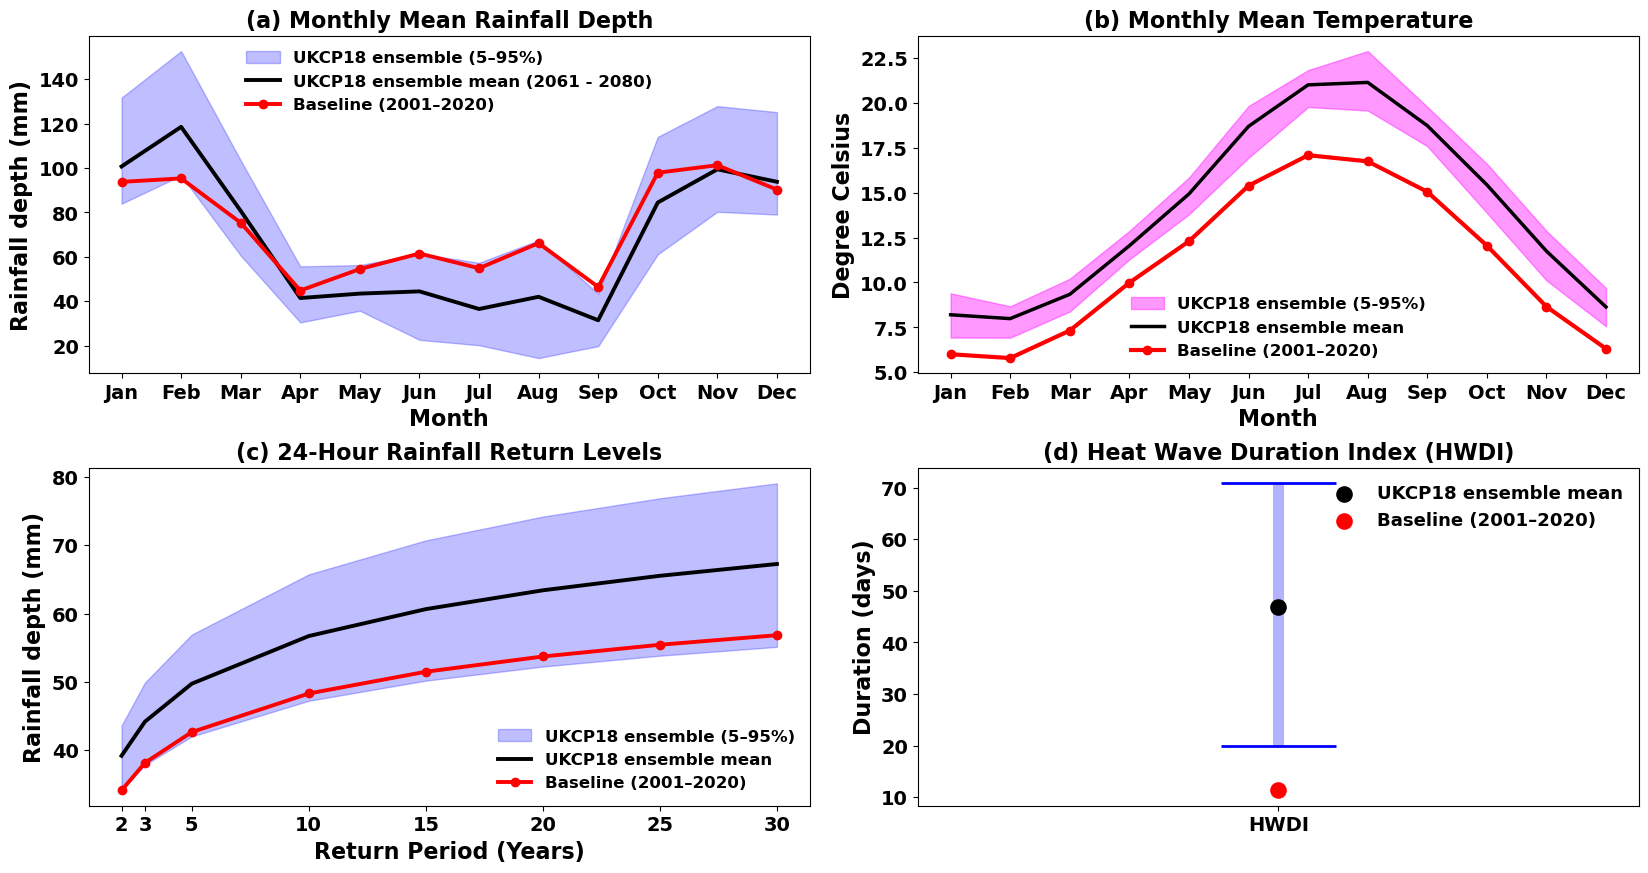

In [13]:
fig = plt.figure(figsize=(20,10))
gs = fig.add_gridspec(2, 2,hspace=0.28,wspace=0.15)
ax1 = fig.add_subplot(gs[0,0])   # Rainfall monthly
ax2 = fig.add_subplot(gs[0,1])   # Temperature monthly
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])

real_cols = [c for c in monthly_mean_real.columns if c.startswith("Realization_")]

member_mean = monthly_mean_real.copy()
member_mean["Mean"] = member_mean[real_cols].mean(axis=1)

# Monthly statistics across the 16 ensemble members
ensemble = member_mean.groupby("Month")["Mean"]
ens_mean = ensemble.mean()
ens_low  = ensemble.quantile(0.05)
ens_high = ensemble.quantile(0.95)

plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['font.weight'] = 'bold'
months = np.arange(1,13)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_names = [calendar.month_abbr[i] for i in range(1, 13)]

member_list = member_mean["Member"].unique()

# 5–95% ensemble envelope
band = ax1.fill_between(ens_mean.index,ens_low,ens_high,color="blue",alpha=0.25,label="UKCP18 ensemble (5–95%)")

# Ensemble mean
ens_line = ax1.plot(ens_mean.index,ens_mean.values,color="black",lw=2.8,label="UKCP18 ensemble mean (2061 - 2080)")
obs_line = ax1.plot(obs_mon_mean.index,obs_mon_mean.values,"-o",color="red",lw=2.8,ms=6,label="Baseline (2001–2020)")
ax1.legend(handles=[band, ens_line[0], obs_line[0]],frameon=False,fontsize=12)
ax1.set_title('(a) Monthly Mean Rainfall Depth', fontsize=16, fontweight='bold')
ax1.set_ylabel('Rainfall depth (mm)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Month', fontsize=16, fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names,fontsize=14,fontweight='bold')
for tick in ax1.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_fontweight('bold')



ensemble = TEMPDF.groupby('Month')
temp_mean = ensemble['temp_mean'].mean()
temp_low  = ensemble['temp_mean'].quantile(0.05)
temp_high = ensemble['temp_mean'].quantile(0.95)
band = ax2.fill_between(temp_mean.index,temp_low,temp_high,color='magenta',alpha=0.40,label='UKCP18 ensemble (5-95%)')
ax2.plot(temp_mean.index,temp_mean.values,color='black',lw=2.5,label='UKCP18 ensemble mean')
obs_line = ax2.plot(months,OBS_TEMP['mean'].values,'-o',color='red',lw=3,label='Baseline (2001–2020)')
ax2.legend(loc='lower center',frameon=False, fontsize=12)
ax2.set_title('(b) Monthly Mean Temperature', fontsize=16, fontweight='bold')
ax2.set_ylabel('Degree Celsius', fontsize=16, fontweight='bold')
ax2.set_xlabel('Month', fontsize=16, fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_names,fontsize=14,fontweight='bold')
for tick in ax2.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_fontweight('bold')



RPS = RPVAL_DF_OBS['RP'].values
for df in REAL_RP_MEAN_LIST:
    df['RP'] = RPS

rp_mean_all = pd.concat(REAL_RP_MEAN_LIST, ignore_index=True)
# Ensemble statistics across members
ensemble = rp_mean_all.groupby('RP')['MEAN']
rp_mean = ensemble.mean()
rp_low  = ensemble.quantile(0.05)
rp_high = ensemble.quantile(0.95)
band = ax3.fill_between(rp_mean.index,rp_low,rp_high,color='blue',alpha=0.25,label='UKCP18 ensemble (5–95%)')
ens_line = ax3.plot(rp_mean.index,rp_mean.values,color='black',lw=2.8,label='UKCP18 ensemble mean')
obs_line = ax3.plot(RPVAL_DF_OBS['RP'],RPVAL_DF_OBS['RF'],'-o',color='red',lw=2.8,ms=6,label='Baseline (2001–2020)')
ax3.set_title('(c) 24-Hour Rainfall Return Levels',fontsize=16, fontweight='bold')
ax3.set_xlabel('Return Period (Years)',fontsize=16, fontweight='bold')
ax3.set_ylabel('Rainfall depth (mm)',fontsize=16, fontweight='bold')
ax3.set_xticks(RPVAL_DF_OBS['RP'])

for tick in ax3.get_xticklabels():
    tick.set_fontsize(14)
    tick.set_fontweight('bold')

for tick in ax3.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_fontweight('bold')

ax3.legend(handles=[band, ens_line[0], obs_line[0]],frameon=False,fontsize=12)


# # Average over the 300 realizations for each UKCP18 member
# HEAT_MEMBER = (HEAT_INDICES_REAL.groupby('Member')[['Hot days', 'Warm Nights', 'Cold Nights', 'HWDI']].mean())
# mean = HEAT_MEMBER.mean()

# low = HEAT_MEMBER.quantile(0.05)

# high = HEAT_MEMBER.quantile(0.95)
# OBS = pd.Series({'Hot days': OBS_MEAN_TMAX,'Warm Nights': OBS_MEAN_TMIN,'Cold Nights': OBS_MEAN_TMIN,'HWDI': OBS_HWDI})

# labels = ['Hot days', 'Warm Nights', 'Cold Nights', 'HWDI']
# x = np.arange(len(labels))

# # 5–95% uncertainty interval
# ax4.vlines(
#     x,
#     low[labels],
#     high[labels],
#     color='blue',
#     lw=8,
#     alpha=0.25
# )

# # Caps
# cap = 0.12
# ax4.hlines(low[labels],  x-cap, x+cap, color='blue', lw=2)
# ax4.hlines(high[labels], x-cap, x+cap, color='blue', lw=2)

# # Ensemble mean
# ax4.scatter(
#     x,
#     mean[labels],
#     color='black',
#     s=100,
#     zorder=5,
#     label='UKCP18 ensemble mean (2061–2080)'
# )

# # Observations
# ax4.scatter(
#     x,
#     OBS[labels],
#     color='red',
#     s=100,
#     zorder=6,
#     label='Baseline (2001–2020)'
# )

# ax4.set_xticks(x)
# ax4.set_xticklabels(labels, fontsize=14, fontweight='bold')

# for tick in ax4.get_yticklabels():
#     tick.set_fontsize(14)
#     tick.set_fontweight('bold')

# ax4.set_ylabel('Annual Count / Duration (days)',
#                fontsize=16,
#                fontweight='bold')

# ax4.set_title('(d) Temperature Extreme Indices',
#               fontsize=16,
#               fontweight='bold')

# ax4.legend(frameon=False, fontsize=13)
HWDI_REAL = HEAT_INDICES_REAL[['Member','HWDI']]
HWDI_MEMBER = (HWDI_REAL.groupby('Member')['HWDI'].mean().reset_index())
hwdi_mean = HWDI_MEMBER['HWDI'].mean()
hwdi_low  = HWDI_MEMBER['HWDI'].quantile(0.05)
hwdi_high = HWDI_MEMBER['HWDI'].quantile(0.95)
x = 1
ax4.vlines(x, hwdi_low, hwdi_high, color='blue', lw=8, alpha=0.3)

# Small horizontal caps
ax4.hlines([hwdi_low, hwdi_high],x-0.08, x+0.08,color='blue', lw=2)

# Ensemble mean
ax4.scatter(x,hwdi_mean,color='black',s=120,zorder=5,label='UKCP18 ensemble mean')
ax4.scatter(x,OBS_HWDI,color='red',s=120,zorder=6,label='Baseline (2001–2020)')
ax4.set_xlim(0.5, 1.5)
ax4.set_xticks([1])
ax4.set_xticklabels(['HWDI'], fontsize=14, fontweight='bold')
ax4.set_ylabel('Duration (days)', fontsize=16, fontweight='bold')
ax4.set_title('(d) Heat Wave Duration Index (HWDI)', fontsize=16, fontweight='bold')
ax4.legend(frameon=False, fontsize=13)
for tick in ax4.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_fontweight('bold')

plt.savefig('/home/users/azhar199/DATA/NEWDATA/GRIDDED_WG_QC/PaperPlots/Figure7.png',dpi=600,bbox_inches='tight')
plt.show()